ESEMPIO PRATICO: cGAN PER GENERARE FASHION MNIST PER CLASSE

Mettiamo in pratica tutto ciò che abbiamo imparato su cGAN
Diamo dei comandi specifici, trasformando faschion MNIST nella nostra scuola guida per la generazione condizionata.
Chiederemo alla macchina di disegnare una borsa o uno stivaletto.

- One-Hot Encoding: come spiegare le categorie alla rete
- Embedding Layers: versione più sofisticata per gestire i concettti semantici.
- Test di Coerenza: verifichiamo se la nostra rete ha davvero imparato o se sta sognando.

Come traduciamo il linguaggio umano in vettori

Per addestrare la nostra cGAN dobbiamo superare un ostalcolo. Le macchine non sanno cos'è una t-shit o una scarpa, sanno solo processare dei numeri.
Il modo più immmediato è one-hot encoding, immagina una tastira con 10 tasti, ognuno per ogni categoria della rete (immaginando che ha 10 laberl) 
E' un sistema binario ma estramamente efficacie

Vettori di Condizionamento
- Ogni classe (y) del dataset viene associato a un indice univoco da 0 a 9 (se 10 sono le classi, le etichette, le y)
- Il vettore riultante ha dimensione pari al numero totale delle classi (10)
- Questa rappresentazione impedisce alla rete di assumere relazioni d'ordine errate tra le classi (es che un cappotto, identificato con il 2, sia la somma di due magliette, identificate con 1)
- In PyTorch, usiamo spesso F.one_hot per generare queste maschere durante il passaggio dei dati ai modelli.
Con il one-hot ogni categoria è un punto isolato e equisolato nello spazio.

Dove inseriamo questo vettore nella rete?

Iniezioni delle Label
è come aggiungere un ingrediente in diverse fasi della ricetta.
Nel Generatore attacchiamo il vettore one-hot al rumore casuale z.
Nel Discriminatore, l etichetta serve come parametro di controllo, se un poliziotto riceve un immagine di pantalone ma l'etichetta dice t-shirt il discriminatore deve scartare l'immagine anche se bellissima

Ma cosa accade matematicamente?
Stiamo passando da una distribuzione semplice a una probabilità condizionata.
L'uso dei vettori one-hot agisce come un selettore di modalità: stiamo dicendo alla rete di campionare da una specifica sottomatrice dela distribuzione globale.
Questo vincolo semplifica enormemente il lavoro del Generatore, permeettendogli di concentrarsi su feature specifiche per ogni categoria.
Lo spazio di tutti i vestiti è vista come l'intera galassia, usando il condizionamento, stiamo dicendo al generatore di ignorare l'intera galassia e di atterrare su un pianeta specifico, esempio quello dei sandali.
Questo semplifica la vita alla rete che non deve imparare a fare tutto contemporaneamente, ma può specializzarsi su feature specifiche, rendendo l'addestramento molto più veloce ed efficace.

Ma se volessimo più fluido e meno rigido del one-hot?

Embedding Layers
One-hot è come un interrutore rigido, ma la moda non è così rigida, ci sono relazioni tra gli oggetti.
Gli strati embedding trasformano indici discreti in vettori densi di numeri reali che la rete impara a ottimizzare durante l'addestramento.
Questo layer è come un traduttore che assegna, ad ogni classe un punto in una mappa semantica, che la rete stessa progetta durante l'addestramento.
E' qui che la cGAN inizia a mostrare una vera intelligenza contestuale.

Rappresentazioni Dense
- Un layer nn.Embedding agisce come una tabella di lookup che associa a ogni classe un vettore di dimensione prefissata (es. 50)
- A differenza del One-hot, il vettore di embedding può catturare la vicinanza strutturale tra classi simili (es. stivaletti e scarpe da ginnastica)
- L'embedding viene aggiornato tramite backpropagation proprio come gli altri pesi della rete
- Questa tecnica riduce la dimensionalità dell'input condizionale ripetto a un approccio one-hot molto sparso.

Efficienza dell'Embedding
Grazie agli embedding il generatore riceve un segnale molto più ricco. Classi visivamente simili tendono a finire in coordinate vicine, facilitando il campito di G. La rete può ri-utilizzare ciò che sa sulla texture pesanti, senza dover ripartire da zero per ogni categoria.
Se le classi sono troppo simili visivamente, il Discriminatore potrebbe far fatica a fornire gradienti precisi per separarle.
Gli embedding permettono di gestire centinaia di classi senza che il vettore di input diventi troppo grande e difficile da processare.

Movimento tra i concetti
Geometria delle Classi
Navigare tra i vestiti.
Grazie agli embedding, possiamo persino provare a interpolare tra due classi diverse (es. generare qualcosa a meta tra una maglietta ed una felpa)
Questa fluidità dimostra che la cGAN ha appreso non solo a copiare, ma a capire le caratteristiche fondamentali di ogni indumento. Ha catturato l'essenza degli indumenti, ha costruito un modello geometrico del guardaroba.

Test di Coerenza
Validare la capacità di obbedire ai comandi.
In un progetto reale non possiamo permetterci che la rete generi una borsa quando l'utente ha chiesto una camicia. Dobbiamo essere sicuri che la nostra cGAN stia davvero seguendo l'etichetta y e non stia semplicemente ignorando l'input condizionale.
Il test definitivo consiste nel generare immagini raggruppate per classe e verificare visivamente la loro correttezza e diversità
Il condizoinamento deve diventare un ordine imperativo e non deve rimanere solo un etichetta che la rete ignora

Griglie 10x10
Monitoragio sistematico dell output
Impostiamo un batch dove ogni riga rappresenta una classe fissa.
La prima solo magliette, la seconda solo pantaloni, se nella grigli non trovo una scarpa in mezzo alla riga delle magliette, il discriminatore non è stato abbastanza severo nell'analizzare la coerenza semantica.

Dobbiamo misurare Fidelity e Diversity
Vogliamo che le immagini siano tutte diverse tra loro, anche all'interno della stessa categoria.
Il discriminatore gioca un ruolo difficile, deve sapere distinguere classi molto simili

Maturità del Modello
All'inizio si vedranno solo delle macchie grigie, e come guardare delle sagome attraverso un vetro appannato. Passando le epoche si vedranno le diverse sfumature, suole, colori, ecc

Possiamo anche utilizzare un discriminatore esterno per valure la nostra rete.

Epoca 30: 100%|██████████| 469/469 [00:23<00:00, 20.03it/s, D_loss=1.43, G_loss=0.773]


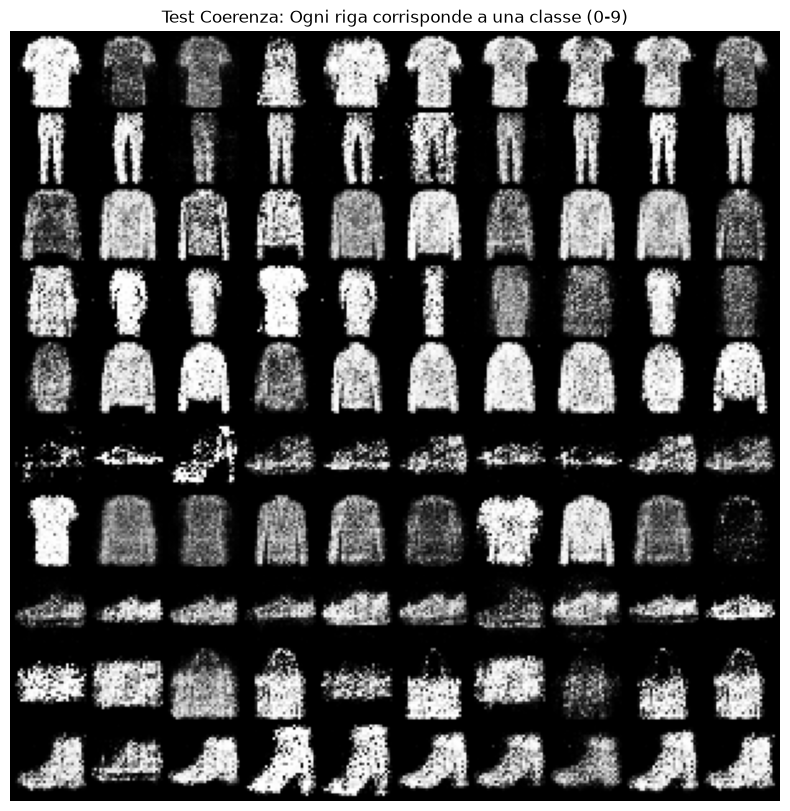

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE E IPERPARAMETRI ---

# Selezione del dispositivo di calcolo: GPU (cuda) se disponibile, altrimenti CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dimensioni dello spazio latente (vettore di rumore casuale)
latent_dim = 100

# Numero di classi nel dataset FashionMNIST (10 tipi di abbigliamento)
n_classes = 10

# Dimensione del vettore di embedding per le etichette. 
# Questo vettore rappresenta le informazioni semantiche della classe in uno spazio continuo.
embed_size = 50 

# Tasso di apprendimento per l'ottimizzatore Adam
lr = 0.0002

# Definizione delle trasformazioni: conversione in tensore e normalizzazione 
# dei pixel nell'intervallo [-1, 1] per favorire la convergenza della GAN.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Caricamento del dataset FashionMNIST e creazione del DataLoader per la gestione dei batch.
train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=128, shuffle=True
)

# --- ARCHITETTURE DEL MODELLO ---

# La classe Generator crea immagini sintetiche partendo da rumore e un'etichetta specifica.
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Trasforma gli indici delle classi in vettori densi di dimensione embed_size.
        self.label_embed = nn.Embedding(n_classes, embed_size)
        
        # Architettura neurale: una sequenza di strati lineari che espandono il vettore 
        # combinato (rumore + embedding) fino a raggiungere la dimensione dell'immagine (28x28).
        self.model = nn.Sequential(
            # L'input è la somma delle dimensioni del rumore e dell'embedding della classe.
            nn.Linear(latent_dim + embed_size, 256), 
            nn.ReLU(True),
            nn.Linear(256, 512), 
            nn.ReLU(True),
            nn.Linear(512, 1024), 
            nn.ReLU(True),
            # L'ultimo strato usa Tanh per mappare i valori nell'intervallo [-1, 1], 
            # coerentemente con la normalizzazione del dataset.
            nn.Linear(1024, 784), 
            nn.Tanh() 
        )

    def forward(self, noise, labels):
        # Converte le etichette numeriche in embedding.
        label_input = self.label_embed(labels)
        # Unisce il vettore di rumore e l'embedding della classe (condizionamento).
        x = torch.cat([noise, label_input], dim=1)
        # Genera l'immagine e la rimodella nel formato (Canale, Altezza, Larghezza).
        return self.model(x).view(-1, 1, 28, 28)

# La classe Discriminator valuta se un'immagine è reale o prodotta dal generatore, 
# considerando anche la coerenza con l'etichetta fornita.
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Anche il discriminatore utilizza un embedding per interpretare la classe.
        self.label_embed = nn.Embedding(n_classes, embed_size)
        
        # Architettura neurale: riceve l'immagine appiattita e l'embedding della classe.
        self.model = nn.Sequential(
            nn.Linear(784 + embed_size, 512), 
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1), 
            # Sigmoide finale per ottenere un valore di probabilità (0=finto, 1=vero).
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Converte le etichette in embedding.
        label_input = self.label_embed(labels)
        # Appiattisce l'immagine (28x28 -> 784) e la concatena con l'embedding.
        x = torch.cat([img.view(-1, 784), label_input], dim=1)
        return self.model(x)

# Inizializzazione dei modelli e spostamento sul dispositivo di calcolo (CPU/GPU).
netG = Generator().to(device)
netD = Discriminator().to(device)

# Funzione di perdita: Binary Cross Entropy, ideale per problemi di classificazione binaria.
criterion = nn.BCELoss()

# Ottimizzatori Adam per entrambi i modelli, con parametri beta specifici per le GAN.
optG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))
optD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))

# --- CICLO DI ADDESTRAMENTO ---

for epoch in range(30):
    # Utilizzo di tqdm per visualizzare una barra di avanzamento durante l'epoca.
    pbar = tqdm(train_loader, desc=f"Epoca {epoch+1}")
    for real_imgs, labels in pbar:
        b_size = real_imgs.size(0)
        real_imgs, labels = real_imgs.to(device), labels.to(device)

        # fase A: ADDESTRAMENTO DEL DISCRIMINATORE
        # L'obiettivo è massimizzare la capacità di distinguere il vero dal falso.
        netD.zero_grad()
        
        # 1. Valutazione sulle immagini reali: l'output dovrebbe tendere a 1.
        out_real = netD(real_imgs, labels)
        loss_real = criterion(out_real, torch.ones(b_size, 1, device=device))

        # 2. Valutazione sulle immagini generate (fake): l'output dovrebbe tendere a 0.
        noise = torch.randn(b_size, latent_dim, device=device)
        fake_imgs = netG(noise, labels)
        # .detach() evita che il gradiente risalga fino al generatore in questa fase.
        out_fake = netD(fake_imgs.detach(), labels)
        loss_fake = criterion(out_fake, torch.zeros(b_size, 1, device=device))

        # Calcolo del gradiente totale e aggiornamento dei pesi del discriminatore.
        (loss_real + loss_fake).backward()
        optD.step()

        # fase B: ADDESTRAMENTO DEL GENERATORE
        # L'obiettivo è creare immagini che portino il discriminatore a sbagliare (output -> 1).
        netG.zero_grad()
        
        # Valutiamo le immagini appena create senza staccare il gradiente.
        out_g = netD(fake_imgs, labels)
        # Calcoliamo la perdita usando etichette "vere" come target per ingannare il discriminatore.
        loss_g = criterion(out_g, torch.ones(b_size, 1, device=device))
        
        # Aggiornamento dei pesi del generatore.
        loss_g.backward()
        optG.step()
        
        # Aggiornamento delle statistiche nella barra di avanzamento.
        pbar.set_postfix(D_loss=loss_real.item()+loss_fake.item(), G_loss=loss_g.item())

# --- VERIFICA DELLA COERENZA DEL MODELLO ---

def test_coherence():
    """Genera una griglia 10x10 dove ogni riga rappresenta una classe specifica."""
    netG.eval()
    
    # Prepariamo 10 campioni per ciascuna delle 10 classi (totale 100 immagini).
    test_labels = torch.arange(10).repeat_interleave(10).to(device)
    # Generiamo rumore casuale per ogni campione.
    test_noise = torch.randn(100, latent_dim, device=device)
    
    with torch.no_grad():
        # Produciamo le immagini ed eseguiamo il download sulla CPU per la visualizzazione.
        samples = netG(test_noise, test_labels).cpu()
    
    # Creazione della griglia visiva.
    grid = utils.make_grid(samples, nrow=10, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Test Coerenza: Ogni riga corrisponde a una classe (0-9)")
    plt.axis('off')
    plt.show()

# Esecuzione del test finale.
test_coherence()